# 🐧 Clasificación de Pingüinos Palmer
## Exploración progresiva de clasificadores: K-Means → SVM → Árbol → RLM → Neurona

**Dataset:** Palmer Penguins (seaborn)  
**Objetivo:** Clasificar la especie de pingüino (`Adelie`, `Chinstrap`, `Gentoo`) a partir de sus características físicas  
**Enfoque** Cada modelo se entrena, se evalúa y se justifica por qué el siguiente es necesario

---

> 📌 **Estructura del notebook:**  
> `Bloque 0` Glosario · `Bloque 1` EDA · `Bloque 2` Preprocesamiento · `Bloque 3` K-Means  
> `Bloque 4` SVM · `Bloque 5` Árbol · `Bloque 6` RLM · `Bloque 7` Neurona  
> `Bloque 8` Comparativa · `Bloque 9` Inferencia · `Bloque 10` Conclusiones

---
## 📖 Bloque 0: Glosario de Términos Clave

| Término | Definición |
|---------|-----------|
| **Feature / Característica** | Variable de entrada usada para predecir (ej: longitud del pico) |
| **Target / Etiqueta** | Variable que queremos predecir (ej: especie del pingüino) |
| **Train / Entrenamiento** | Subconjunto del dataset con el que el modelo aprende |
| **Test / Prueba** | Subconjunto reservado para evaluar; nunca visto durante el entrenamiento |
| **Normalización (StandardScaler)** | Transforma features a media 0 y desv. estándar 1 para que ninguna domine |
| **One-Hot Encoding** | Convierte variables categóricas en columnas binarias (0 o 1) |
| **Overfitting** | El modelo memoriza el dataset de entrenamiento y falla con datos nuevos |
| **Accuracy** | Porcentaje de predicciones correctas sobre el total |
| **F1-Score (Macro)** | Media armónica entre Precision y Recall; útil con clases balanceadas |
| **Precision** | De todas las veces que predije clase X, ¿cuántas realmente eran X? |
| **Recall** | De todos los ejemplos reales de clase X, ¿cuántos detecté correctamente? |
| **Matriz de Confusión** | Tabla que muestra predicciones correctas e incorrectas por clase |
| **Hiperparámetro** | Configuración del modelo definida *antes* del entrenamiento (ej: profundidad del árbol) |
| **Silhouette Score** | Métrica de calidad para clustering; valores cercanos a 1 = clusters bien definidos |
| **Kernel (SVM)** | Función que transforma el espacio de features para separar clases no lineales |
| **Softmax** | Función que convierte salidas numéricas en probabilidades que suman 1 |
| **Backpropagation** | Algoritmo que ajusta pesos en una red neuronal propagando el error hacia atrás |
| **Epoch / Época** | Una pasada completa por todos los datos de entrenamiento en una red neuronal |
| **PCA** | Reducción de dimensionalidad para visualizar datos multidimensionales en 2D |

---
## 🎯 El Problema

El dataset **Palmer Penguins** contiene mediciones físicas de 344 pingüinos de 3 especies,  
recolectadas en el Archipiélago Palmer (Antártida):

- 🐧 **Adelie** — La más pequeña y abundante; pico corto y redondeado
- 🐧 **Chinstrap** — Identificada por la línea negra bajo el mentón
- 🐧 **Gentoo** — La más grande; pico naranja brillante y aletas largas

### Variables del dataset

| Variable | Tipo | Rol |
|----------|------|-----|
| `species` | Categórica | ✅ **Variable objetivo (target)** |
| `island` | Categórica | Feature → One-Hot Encoding |
| `bill_length_mm` | Numérica | Feature → Normalización |
| `bill_depth_mm` | Numérica | Feature → Normalización |
| `flipper_length_mm` | Numérica | Feature → Normalización |
| `body_mass_g` | Numérica | Feature → Normalización |
| `sex` | Categórica | Feature → One-Hot Encoding |

### Analogía con Iris
> 💡 Este dataset es prácticamente el **"Iris de pingüinos"**: features numéricas continuas, 3 clases, tamaño manejable (~333 filas limpias). La diferencia es que Palmer Penguins tiene contexto más rico e intuitivo.

In [35]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Modelos
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    silhouette_score
)

print("✅ Imports cargados correctamente")

✅ Imports cargados correctamente


---
## 📊 Bloque 1: Carga y Exploración del Dataset (EDA)

Antes de aplicar cualquier modelo, es fundamental **conocer los datos**:
- ¿Cuántos registros y columnas tenemos?
- ¿Hay valores faltantes (NaN)?
- ¿Cómo se distribuyen las clases?
- ¿Qué relación existe entre las features?

> 🔍 El EDA no es opcional — un modelo entrenado con datos mal entendidos siempre dará resultados pobres.

In [36]:
# ── Cargar dataset ─────────────────────────────────────────
df = sns.load_dataset("penguins")

print(f"📐 Dimensiones originales: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\n🔍 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n📊 Distribución de especies:")
print(df['species'].value_counts())
print(f"\n📋 Tipos de datos:")
print(df.dtypes)

display(df.head())

📐 Dimensiones originales: 344 filas × 7 columnas

🔍 Valores nulos por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

📊 Distribución de especies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

📋 Tipos de datos:
species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


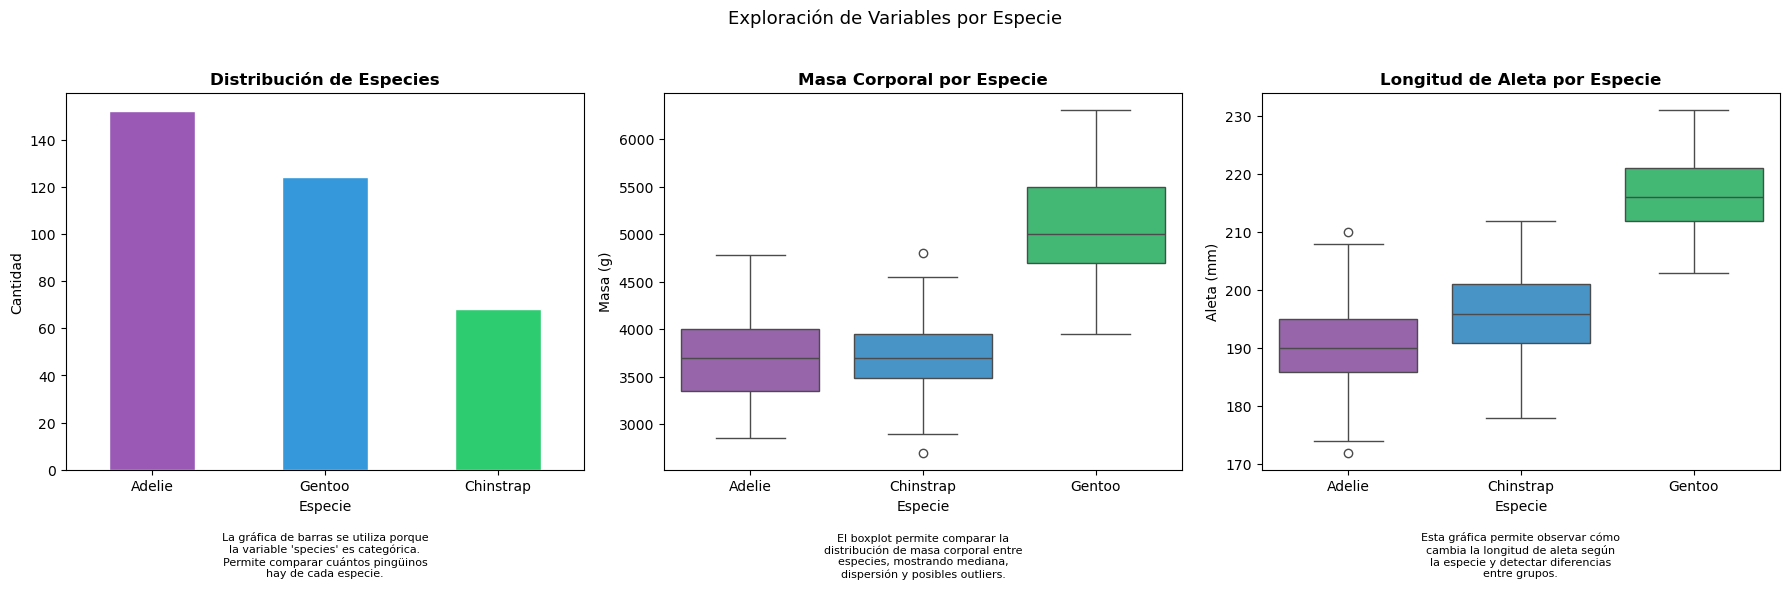


PAIRPLOT - RELACIÓN ENTRE VARIABLES

¿Por qué se usa?
- Permite analizar relaciones entre múltiples variables numéricas.
- Ayuda a identificar correlaciones y separación entre especies.

¿Qué observamos?
- Gentoo presenta mayor masa corporal y mayor longitud de aleta.
- Existe correlación positiva entre masa corporal y longitud de aleta.
- Las especies forman grupos relativamente separados.

¿Por qué es útil?
- Estas separaciones visuales indican que las variables podrían
  funcionar bien para modelos de clasificación.



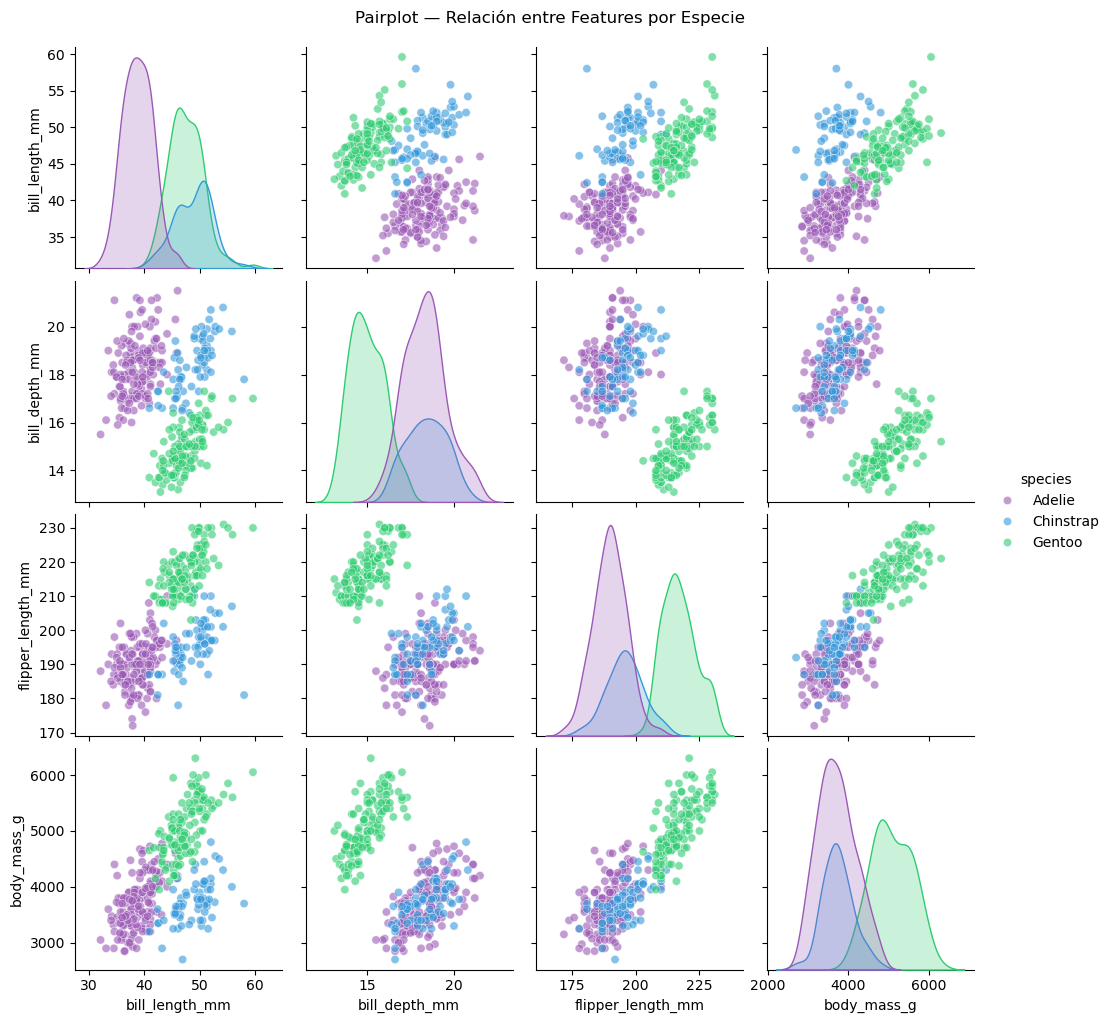

In [37]:
# ── Visualizaciones EDA ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 7))


# 1. Conteo de especies
df['species'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#9b59b6','#3498db','#2ecc71'], edgecolor='white')
axes[0].set_title('Distribución de Especies', fontweight='bold')
axes[0].set_xlabel('Especie'); axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)
axes[0].text(
    0.5, -0.28,
    "La gráfica de barras se utiliza porque\n"
    "la variable 'species' es categórica.\n"
    "Permite comparar cuántos pingüinos\n"
    "hay de cada especie.",
    
    transform=axes[0].transAxes,
    ha='center',
    fontsize=8,
    wrap=True
)

# 2. Masa corporal por especie
sns.boxplot(data=df, x='species', y='body_mass_g',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[1])
axes[1].set_title('Masa Corporal por Especie', fontweight='bold')
axes[1].set_xlabel('Especie'); axes[1].set_ylabel('Masa (g)')
axes[1].text(
    0.5, -0.28,
    "El boxplot permite comparar la\n"
    "distribución de masa corporal entre\n"
    "especies, mostrando mediana,\n"
    "dispersión y posibles outliers.",
    
    transform=axes[1].transAxes,
    ha='center',
    fontsize=8,
    wrap=True
)

# 3. Longitud de aleta por especie
sns.boxplot(data=df, x='species', y='flipper_length_mm',
            palette=['#9b59b6','#3498db','#2ecc71'], ax=axes[2])
axes[2].set_title('Longitud de Aleta por Especie', fontweight='bold')
axes[2].set_xlabel('Especie'); axes[2].set_ylabel('Aleta (mm)')
axes[2].text(
    0.5, -0.28,
    "Esta gráfica permite observar cómo\n"
    "cambia la longitud de aleta según\n"
    "la especie y detectar diferencias\n"
    "entre grupos.",
    
    transform=axes[2].transAxes,
    ha='center',
    fontsize=8,
    wrap=True
)

# Ajustes generales
plt.suptitle('Exploración de Variables por Especie', fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0.12, 1, 1]); plt.show()

# ── Pairplot: relación entre features numéricas ─────────────
print("""
PAIRPLOT - RELACIÓN ENTRE VARIABLES

¿Por qué se usa?
- Permite analizar relaciones entre múltiples variables numéricas.
- Ayuda a identificar correlaciones y separación entre especies.

¿Qué observamos?
- Gentoo presenta mayor masa corporal y mayor longitud de aleta.
- Existe correlación positiva entre masa corporal y longitud de aleta.
- Las especies forman grupos relativamente separados.

¿Por qué es útil?
- Estas separaciones visuales indican que las variables podrían
  funcionar bien para modelos de clasificación.
""")
sns.pairplot(df, hue='species',
             vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'],
             palette=['#9b59b6','#3498db','#2ecc71'],
             plot_kws={'alpha': 0.6}, diag_kind='kde')
plt.suptitle('Pairplot — Relación entre Features por Especie', y=1.02)
plt.show()

In [38]:
# ============================================================
# EXPLICACIÓN DE LAS GRÁFICAS UTILIZADAS EN EL EDA
# ============================================================

print("""
==================== EXPLICACIÓN DEL EDA ====================

El Análisis Exploratorio de Datos (EDA) se utiliza para comprender la estructura del dataset antes de aplicar los modelos de Machine Learning.

Las gráficas seleccionadas permiten responder preguntas distintas sobre los datos de los pingüinos.

------------------------------------------------------------
1. GRÁFICA DE BARRAS (Distribución de especies)
------------------------------------------------------------

¿Por qué se usa?
- Porque la variable 'species' es categórica.
- Las gráficas de barras son ideales para comparar cantidades entre categorías.

¿Qué nos permite observar?
- Cuántos pingüinos hay de cada especie.
- Si el dataset está balanceado o desbalanceado.

¿Por qué NO usar otras gráficas?
- Un histograma no sirve bien para categorías.
- Una gráfica de líneas tampoco es adecuada porque no existe una secuencia temporal.

Conclusión:
La gráfica de barras permite visualizar rápidamente la frecuencia de cada especie.

------------------------------------------------------------
2. BOXPLOT (Masa corporal por especie)
------------------------------------------------------------

¿Por qué se usa?
- Porque queremos comparar una variable numérica ('body_mass_g') entre diferentes grupos ('species').

¿Qué muestra un boxplot?
- Mediana (línea central)
- Rango intercuartil
- Valores mínimos y máximos
- Posibles valores atípicos (outliers)

¿Qué nos permite analizar?
- Diferencias de masa entre especies.
- Variabilidad de cada grupo.
- Presencia de datos extremos.

¿Por qué NO usar solo promedios?
- El promedio puede ocultar dispersión y outliers.
- El boxplot muestra mejor la distribución completa.

Conclusión:
El boxplot ayuda a comparar cómo cambia la masa corporal dependiendo de la especie.

------------------------------------------------------------
3. BOXPLOT (Longitud de aleta por especie)
------------------------------------------------------------

¿Por qué se usa?
- Porque nuevamente se compara una variable numérica ('flipper_length_mm') entre categorías.

¿Qué nos permite detectar?
- Qué especie tiene aletas más largas.
- Qué tan dispersos están los datos.
- Si existen diferencias claras entre especies.

¿Por qué es útil?
- Ayuda a identificar si esta variable podría servir para clasificar especies en Machine Learning.

Conclusión:
La longitud de aleta parece separar bastante bien a las especies.

------------------------------------------------------------
4. PAIRPLOT (Relación entre variables numéricas)
------------------------------------------------------------

¿Por qué se usa?
- Porque permite analizar múltiples variables al mismo tiempo.

¿Qué muestra?
- Relación entre pares de variables.
- Distribución individual de cada feature.
- Posibles correlaciones.
- Separación natural entre especies.

¿Qué observamos en este dataset?
- Los pingüinos Gentoo tienen mayor masa corporal y aletas más largas.
- Algunas variables presentan correlación positiva.
- Existen grupos visualmente separables.

¿Por qué es importante?
- Ayuda a decidir qué variables son útiles para clasificación o predicción.

¿Por qué NO usar tablas solamente?
- Las relaciones entre variables son difíciles de detectar numéricamente.
- Visualmente es más fácil identificar patrones.

Conclusión:
El pairplot es una herramienta poderosa para descubrir relaciones entre features y posibles agrupamientos.

============================================================
RESUMEN GENERAL
============================================================

Cada gráfica fue seleccionada según el tipo de variable y el objetivo del análisis:

- Barras  -> comparar categorías
- Boxplot -> comparar distribuciones numéricas
- Pairplot -> analizar relaciones múltiples

Estas visualizaciones permiten entender el comportamiento del dataset antes de entrenar modelos de Machine Learning.
============================================================
""")


==================== EXPLICACIÓN DEL EDA ====================

El Análisis Exploratorio de Datos (EDA) se utiliza para comprender la estructura del dataset antes de aplicar los modelos de Machine Learning.

Las gráficas seleccionadas permiten responder preguntas distintas sobre los datos de los pingüinos.

------------------------------------------------------------
1. GRÁFICA DE BARRAS (Distribución de especies)
------------------------------------------------------------

¿Por qué se usa?
- Porque la variable 'species' es categórica.
- Las gráficas de barras son ideales para comparar cantidades entre categorías.

¿Qué nos permite observar?
- Cuántos pingüinos hay de cada especie.
- Si el dataset está balanceado o desbalanceado.

¿Por qué NO usar otras gráficas?
- Un histograma no sirve bien para categorías.
- Una gráfica de líneas tampoco es adecuada porque no existe una secuencia temporal.

Conclusión:
La gráfica de barras permite visualizar rápidamente la frecuencia de cada especi

---
## ⚙️ Bloque 2: Preprocesamiento Unificado

Este bloque prepara los datos **una sola vez** y de forma válida para todos los modelos.

### Pasos:
1. **Eliminar NaN** — los modelos no toleran valores faltantes
2. **Codificar el target** — `species` → `0` (Adelie), `1` (Chinstrap), `2` (Gentoo)
3. **One-Hot Encoding** — `island` y `sex` → columnas binarias
4. **Train/Test Split** — 80% entrenamiento, 20% prueba, estratificado
5. **StandardScaler** — ajustado *solo* con datos de entrenamiento

> ⚠️ **¿Por qué escalar DESPUÉS del split?**  
> Si ajustamos el scaler con *todos* los datos, el modelo "vería" información del test durante el entrenamiento — eso se llama **data leakage** y produce métricas artificialmente optimistas.

> ⚠️ **¿Por qué hacer clones / copias?**  
> Al hacer `train_test_split`, obtenemos arrays numpy independientes. Cada modelo recibe sus propias copias para evitar que modificaciones de un modelo afecten a los demás.

In [39]:
# ── 1. Limpiar valores nulos ────────────────────────────────
df_clean = df.dropna().reset_index(drop=True)
print(f"✅ Filas originales: {len(df)} | Filas después de limpiar NaN: {len(df_clean)}")

# ── 2. Codificar target ─────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df_clean['species'])
class_names = le.classes_
print(f"\n🏷️  Codificación de clases: {dict(enumerate(class_names))}")

# ── 3. One-Hot Encoding de variables categóricas ────────────
df_features = df_clean.drop(columns=['species'])
df_encoded  = pd.get_dummies(df_features, columns=['island', 'sex'], drop_first=False)
feature_names = df_encoded.columns.tolist()
print(f"\n📋 Features tras One-Hot Encoding ({len(feature_names)} columnas):")
print(feature_names)

# ── 4. Convertir a numpy ────────────────────────────────────
X_raw = df_encoded.values.astype(float)

# ── 5. Split ANTES de escalar (evitar data leakage) ────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Mantiene proporción de clases en cada split
)

# ── 6. Escalar SOLO con datos de entrenamiento ──────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform en train
X_test  = scaler.transform(X_test_raw)         # solo transform en test

print(f"\n📐 Shape Train: {X_train.shape} | Shape Test: {X_test.shape}")
print(f"📊 Clases en train: {dict(zip(class_names, np.bincount(y_train)))}")
print(f"📊 Clases en test:  {dict(zip(class_names, np.bincount(y_test)))}")

✅ Filas originales: 344 | Filas después de limpiar NaN: 333

🏷️  Codificación de clases: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

📋 Features tras One-Hot Encoding (9 columnas):
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island_Biscoe', 'island_Dream', 'island_Torgersen', 'sex_Female', 'sex_Male']

📐 Shape Train: (266, 9) | Shape Test: (67, 9)
📊 Clases en train: {'Adelie': np.int64(117), 'Chinstrap': np.int64(54), 'Gentoo': np.int64(95)}
📊 Clases en test:  {'Adelie': np.int64(29), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(24)}


In [40]:
# ============================================================
# FUNCIONES AUXILIARES REUTILIZABLES
# Estas funciones se usan en cada bloque de modelo para mantener el código limpio y consistente.
# ============================================================

resultados = {}   # Acumula métricas de todos los modelos para la tabla final

def plot_confusion_matrix(y_true, y_pred, title):
    """Grafica la matriz de confusión con heatmap de colores."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Real', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def print_metrics(y_true, y_pred, model_name):
    """Imprime métricas principales y guarda en el dict global 'resultados'."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    pre = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')

    print(f"\n{'═'*52}")
    print(f"  📈 Métricas — {model_name}")
    print(f"{'═'*52}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
    print(f"  F1-Macro  : {f1:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"{'═'*52}")

    # Guardar para la tabla comparativa del Bloque 8
    resultados[model_name] = {
        'Accuracy':  round(acc, 4),
        'F1-Macro':  round(f1, 4),
        'Precision': round(pre, 4),
        'Recall':    round(rec, 4)
    }
    return acc, f1


print("✅ Funciones auxiliares listas")

✅ Funciones auxiliares listas


---
## 🔵 Bloque 3: K-Means

### ¿Qué es K-Means?
K-Means es un algoritmo de **aprendizaje no supervisado**: no usa etiquetas durante el entrenamiento.  
Agrupa los datos en **K clusters** minimizando la distancia de cada punto al centroide de su cluster.

### ¿Cómo funciona? (paso a paso)
1. Se inicializan K centroides (aleatoriamente o con k-means++)
2. Cada punto se asigna al centroide más cercano (distancia euclidiana)
3. Los centroides se recalculan como el promedio de sus puntos asignados
4. Se repite hasta convergencia (los centroides ya no se mueven)

### ¿Por qué empezamos aquí?
Queremos explorar si las especies se separan **naturalmente** en el espacio de features, sin usar ningún conocimiento previo de las etiquetas. Es el punto de partida más "honesto".

### Métricas para clustering (distintas a clasificación)
- **Silhouette Score** (−1 a 1): qué tan compactos y separados están los clusters. Valores > 0.5 son buenos.
- **Inercia**: suma de distancias al cuadrado de cada punto a su centroide. Menor es mejor.

📐 Silhouette Score : 0.3975  (1 = clusters perfectos)
📐 Inercia (train)  : 1079.49  (menor = más compacto)

════════════════════════════════════════════════════
  📈 Métricas — K-Means
════════════════════════════════════════════════════
  Accuracy  : 0.7910  (79.1%)
  F1-Macro  : 0.6019
  Precision : 0.5581
  Recall    : 0.6667
════════════════════════════════════════════════════


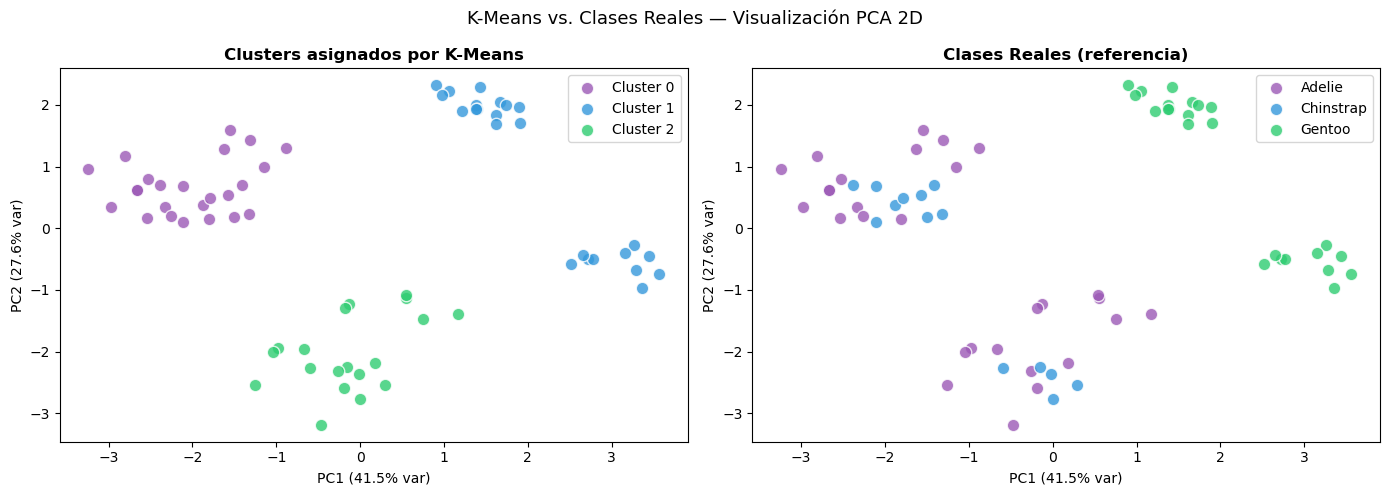

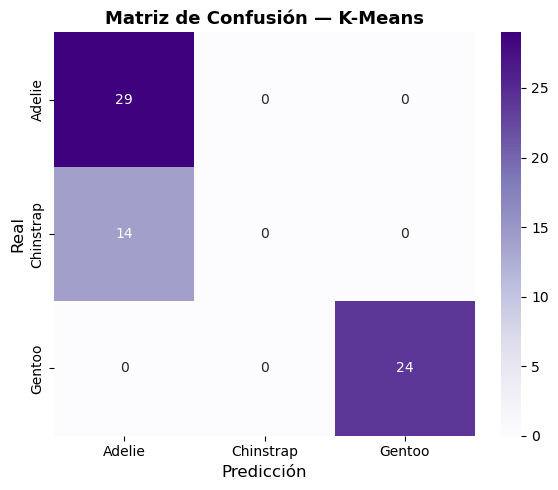

In [41]:
# ── Entrenamiento K-Means ───────────────────────────────────
# n_clusters=3 porque sabemos que hay 3 especies (conocimiento externo)
# n_init=10 para probar 10 inicializaciones diferentes y elegir la mejor
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train)

clusters_test = kmeans.predict(X_test)

# ── Mapear clusters a clases reales ────────────────────────
# K-Means asigna etiquetas arbitrarias (0,1,2) sin saber qué especie es cuál.
# Usamos los datos de test para encontrar el mapeo más frecuente.
# OJO: Esto es un truco para evaluar — en producción real no tendríamos y_test.
label_map = {}
for cluster_id in range(3):
    mask = clusters_test == cluster_id
    if mask.sum() > 0:
        label_map[cluster_id] = int(np.bincount(y_test[mask]).argmax())
    else:
        label_map[cluster_id] = cluster_id

y_pred_kmeans = np.array([label_map[c] for c in clusters_test])

# ── Métricas específicas de clustering ──────────────────────
sil = silhouette_score(X_test, clusters_test)
print(f"📐 Silhouette Score : {sil:.4f}  (1 = clusters perfectos)")
print(f"📐 Inercia (train)  : {kmeans.inertia_:.2f}  (menor = más compacto)")

print_metrics(y_test, y_pred_kmeans, "K-Means")

# ── Visualización: K-Means vs Clases Reales (PCA 2D) ────────
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test)
palette = ['#9b59b6', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters asignados por K-Means
for i in range(3):
    mask = clusters_test == i
    axes[0].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=f'Cluster {i}', alpha=0.8,
                    edgecolors='white', s=80)
axes[0].set_title('Clusters asignados por K-Means', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()

# Clases reales para comparar
for i, name in enumerate(class_names):
    mask = y_test == i
    axes[1].scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                    c=palette[i], label=name, alpha=0.8,
                    edgecolors='white', s=80)
axes[1].set_title('Clases Reales (referencia)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend()

plt.suptitle('K-Means vs. Clases Reales — Visualización PCA 2D', fontsize=13)
plt.tight_layout(); plt.show()

plot_confusion_matrix(y_test, y_pred_kmeans, "Matriz de Confusión — K-Means")

### ⚠️ Limitaciones de K-Means → ¿Por qué necesitamos algo más?

1. **No supervisado:** No usa las etiquetas reales. El mapeo que hicimos (cluster → especie) es un parche manual que en la práctica real no podríamos hacer.
2. **Asume clusters esféricos:** Minimiza distancias euclidianas, lo que lo sesga hacia clusters de forma circular y tamaño similar. Si las clases tienen formas irregulares, falla.
3. **No predice con certeza:** K-Means no produce probabilidades, solo asignaciones de grupo.
4. **Sensible a la escala y a outliers:** Los centroides pueden verse arrastrados por valores extremos.

> 💡 **Siguiente paso:** Usemos las etiquetas reales para entrenar un modelo que aprenda a **separar clases con un margen óptimo** — **SVM (Support Vector Machine)**.

---
## 🔴 Bloque 4: Support Vector Machine (SVM)

### ¿Qué es SVM?
SVM es un algoritmo de **clasificación supervisada** que busca el **hiperplano óptimo** que maximiza el margen entre las clases. En problemas no lineales, usa el **kernel trick**: transforma los datos a un espacio de mayor dimensión donde sí son linealmente separables.

### ¿Cómo funciona?
1. Identifica los puntos más cercanos al límite de decisión (**vectores de soporte**)
2. Maximiza la distancia (margen) entre esos puntos y el hiperplano
3. Con `kernel='rbf'`, aplica una transformación gaussiana para capturar relaciones no lineales

### Parámetros importantes
- **C**: controla el trade-off entre margen máximo y errores de clasificación. C grande = menos errores, más riesgo de overfitting.
- **gamma**: controla el radio de influencia de cada vector de soporte. `'scale'` lo ajusta automáticamente.

### Ventajas sobre K-Means
- ✅ Supervisado: aprende directamente de las etiquetas reales
- ✅ Efectivo en espacios de alta dimensión
- ✅ Robusto al overfitting gracias al principio de margen máximo


════════════════════════════════════════════════════
  📈 Métricas — SVM (kernel RBF)
════════════════════════════════════════════════════
  Accuracy  : 0.9851  (98.5%)
  F1-Macro  : 0.9827
  Precision : 0.9778
  Recall    : 0.9885
════════════════════════════════════════════════════


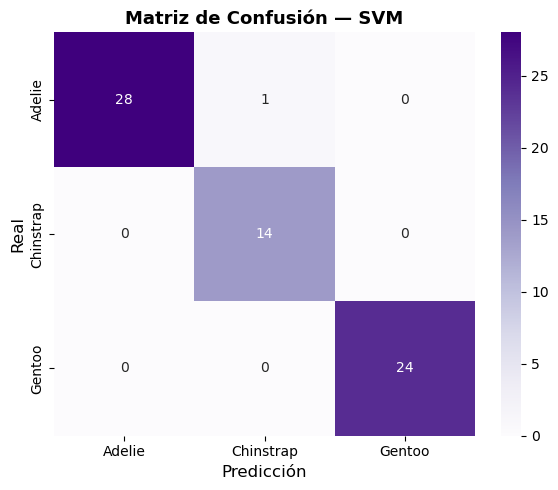


📋 Reporte detallado por clase:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



In [42]:
# ── Entrenamiento SVM ───────────────────────────────────────
svm = SVC(
    kernel='rbf',        # Kernel gaussiano — captura relaciones no lineales
    C=1.0,               # Regularización estándar
    gamma='scale',       # gamma = 1 / (n_features * X.var()) — ajuste automático
    random_state=42,
    probability=True     # Activa predict_proba (necesario para inferencia)
)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

# ── Métricas ────────────────────────────────────────────────
print_metrics(y_test, y_pred_svm, "SVM (kernel RBF)")
plot_confusion_matrix(y_test, y_pred_svm, "Matriz de Confusión — SVM")

# ── Reporte detallado por clase ─────────────────────────────
print("\n📋 Reporte detallado por clase:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

### ⚠️ Limitaciones de SVM → ¿Por qué necesitamos algo más?

1. **Caja negra:** El hiperplano de decisión no es intuitivo. Si alguien pregunta "¿por qué clasificó como Gentoo?", SVM no puede dar una respuesta clara en términos de las features originales.
2. **Difícil de interpretar:** No hay reglas del tipo "si el pico mide más de X mm y la aleta más de Y mm, entonces es Gentoo".
3. **Costo computacional:** Con datasets grandes, el entrenamiento es cuadrático en el número de muestras.
4. **Requiere normalización obligatoria:** Muy sensible a la escala de las features (crítico si alguien olvida este paso).

> 💡 **Siguiente paso:** Necesitamos un modelo **completamente interpretable** que genere reglas de decisión claras y visualizables — **Árbol de Decisión**.

---
## 🟢 Bloque 5: Árbol de Decisión

### ¿Qué es un Árbol de Decisión?
Un árbol de decisión aprende una serie de **reglas if-then-else** sobre las features para clasificar los datos. Es uno de los modelos más interpretables que existen: puedes seguir visualmente el camino de cualquier predicción.

### ¿Cómo funciona?
1. En la raíz, selecciona el feature y umbral que mejor **reduce la impureza** (criterio Gini)
2. Divide los datos en dos subconjuntos (izquierda y derecha)
3. Repite recursivamente en cada subconjunto hasta que:
   - Todos los ejemplos de un nodo son de la misma clase (**hoja pura**), o
   - Se alcanza la profundidad máxima (`max_depth`)

### Impureza de Gini
> Mide qué tan "mezcladas" están las clases en un nodo.  
> `Gini = 1 - Σ p²ᵢ` donde pᵢ es la proporción de cada clase.  
> Gini = 0 significa nodo puro (solo una clase). Gini = 0.67 significa clases equitativas (peor caso con 3 clases).

### Ventajas sobre SVM
- ✅ **100% interpretable:** cada predicción sigue un camino de reglas legibles
- ✅ No requiere normalización de datos
- ✅ Visualizable como diagrama


════════════════════════════════════════════════════
  📈 Métricas — Árbol de Decisión
════════════════════════════════════════════════════
  Accuracy  : 0.9552  (95.5%)
  F1-Macro  : 0.9518
  Precision : 0.9468
  Recall    : 0.9607
════════════════════════════════════════════════════


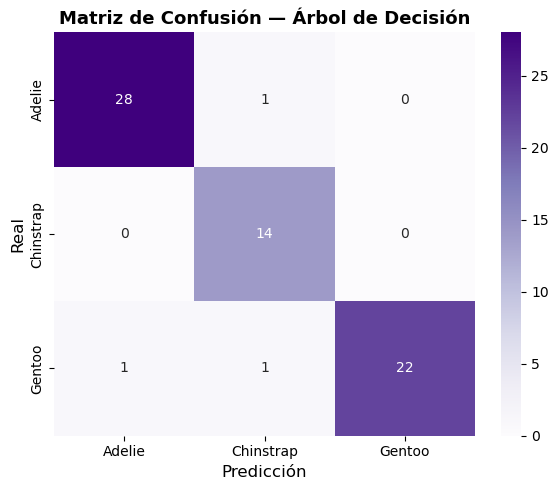

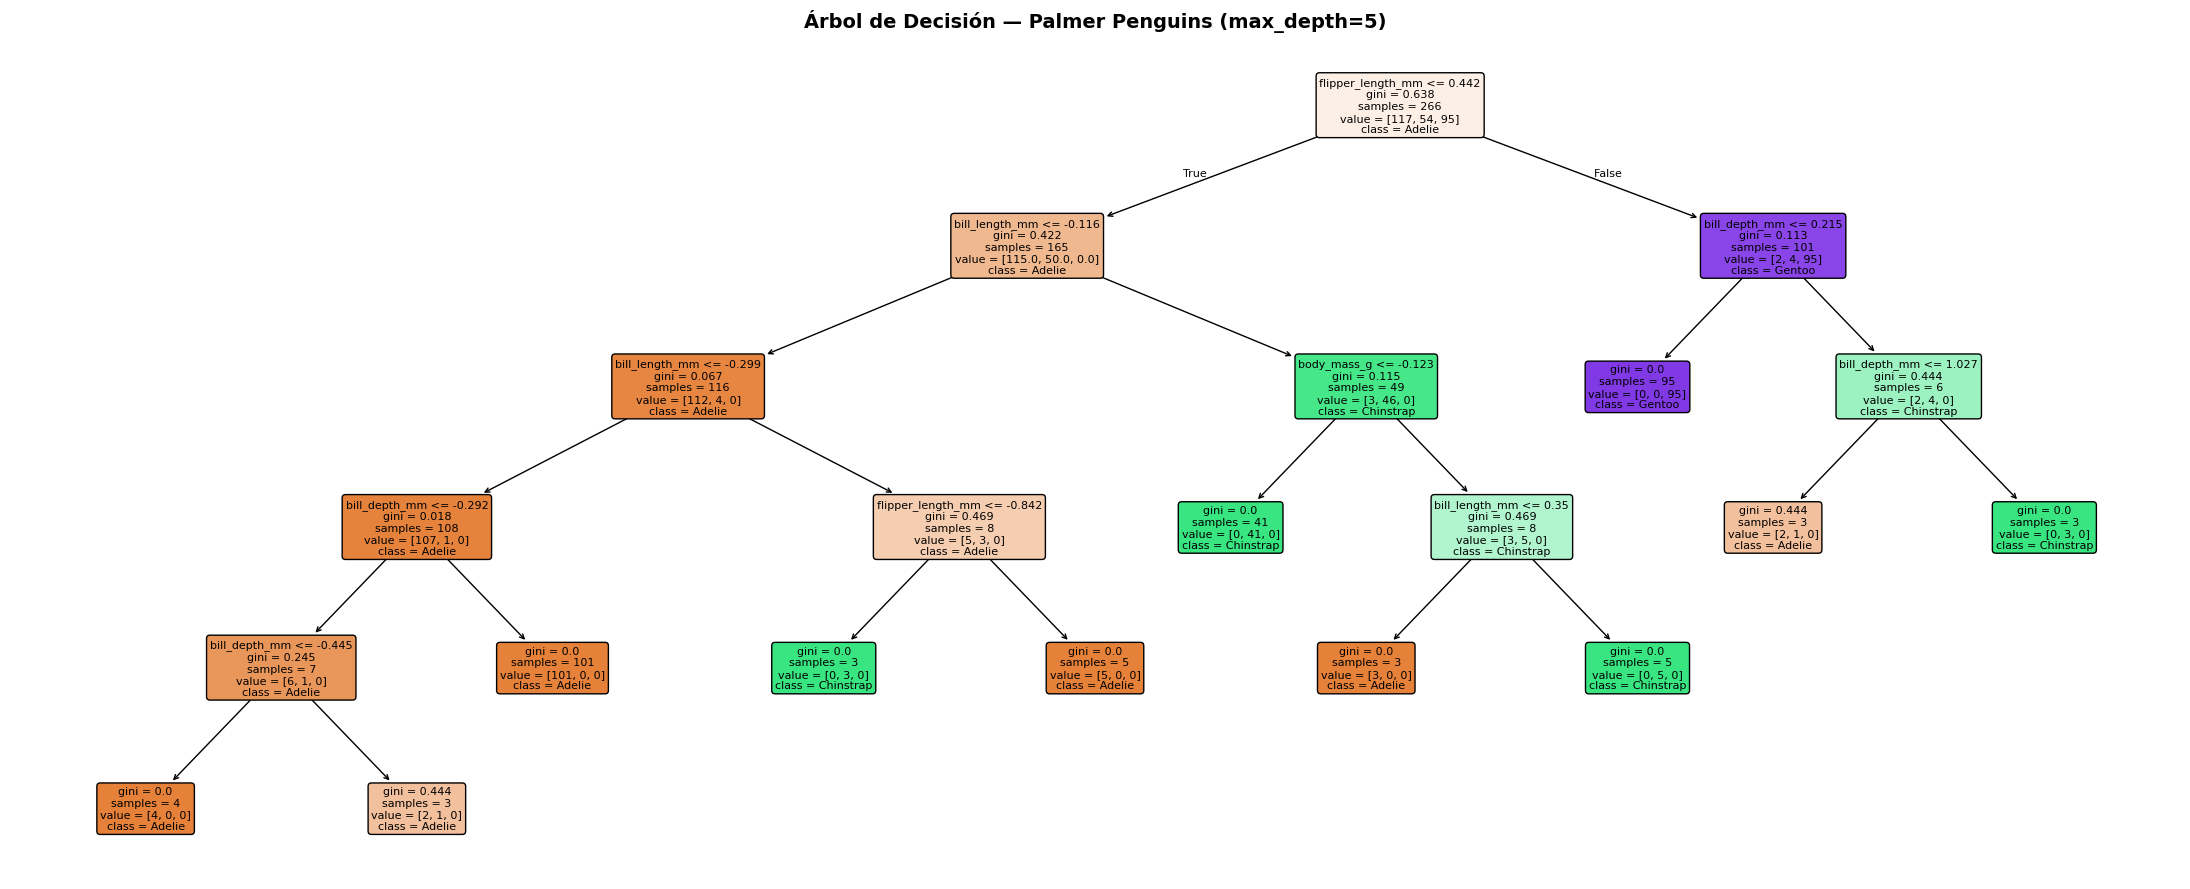

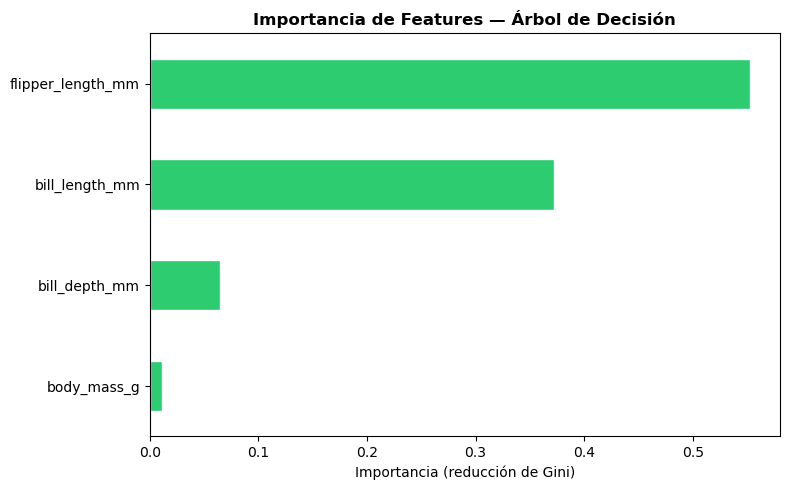


🌳 Profundidad real del árbol: 5
🌳 Número de hojas: 11


In [43]:
# ── Entrenamiento Árbol de Decisión ─────────────────────────
arbol = DecisionTreeClassifier(
    max_depth=5,           # Límite de profundidad para controlar overfitting
    criterion='gini',      # Impureza de Gini como criterio de split
    min_samples_leaf=3,    # Mínimo de muestras en cada hoja
    random_state=42
)
arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)

# ── Métricas ────────────────────────────────────────────────
print_metrics(y_test, y_pred_arbol, "Árbol de Decisión")
plot_confusion_matrix(y_test, y_pred_arbol, "Matriz de Confusión — Árbol de Decisión")

# ── Visualizar el árbol completo ─────────────────────────────
plt.figure(figsize=(22, 9))
plot_tree(
    arbol,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True,
    proportion=False
)
plt.title("Árbol de Decisión — Palmer Penguins (max_depth=5)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Importancia de features ─────────────────────────────────
# Indica cuánto contribuye cada feature a la reducción de impureza
importances = pd.Series(arbol.feature_importances_, index=feature_names)
importances_sorted = importances[importances > 0].sort_values()

plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Importancia de Features — Árbol de Decisión', fontweight='bold')
plt.xlabel('Importancia (reducción de Gini)')
plt.tight_layout(); plt.show()

print(f"\n🌳 Profundidad real del árbol: {arbol.get_depth()}")
print(f"🌳 Número de hojas: {arbol.get_n_leaves()}")

### ⚠️ Limitaciones del Árbol → ¿Por qué necesitamos algo más?

1. **Overfitting:** Sin `max_depth`, el árbol memoriza perfectamente el entrenamiento y falla en datos nuevos. Incluso con restricciones, es un problema latente.
2. **Fronteras rectangulares:** Las decisiones siempre son "mayor/menor que un umbral" — produce límites angulares que no capturan bien bordes curvos.
3. **Inestable:** Cambios pequeños en los datos pueden producir árboles completamente diferentes (alta varianza).
4. **Probabilidades poco confiables:** La probabilidad que reporta es simplemente la proporción de cada clase en la hoja, no una estimación probabilística real.

> 💡 **Siguiente paso:** Necesitamos un modelo que produzca **probabilidades calibradas y reales**, que sea más estable y que sea interpretable en términos de los pesos de cada feature — **Regresión Logística Multinomial**.

---
## 🟠 Bloque 6: Regresión Logística Multinomial (RLM)

### ¿Qué es la Regresión Logística Multinomial?
A pesar del nombre "regresión", este modelo es un **clasificador probabilístico**. Extiende la regresión logística binaria a múltiples clases usando la función **softmax**.

### ¿Cómo funciona?
1. Para cada clase k, calcula una combinación lineal de las features:  
   `zₖ = w₁ₖ·x₁ + w₂ₖ·x₂ + ... + wₙₖ·xₙ + bₖ`
2. Aplica **softmax** para convertir en probabilidades:  
   `P(clase k | x) = exp(zₖ) / Σⱼ exp(zⱼ)` (las probabilidades suman 1)
3. Predice la clase con mayor probabilidad
4. Se entrena minimizando la **entropía cruzada** (cross-entropy loss)

### ¿Por qué se llama "lineal"?
Porque las fronteras de decisión entre clases son **hiperplanos lineales** en el espacio de features. Esto es su principal limitación: si los datos requieren fronteras curvas, el modelo no puede aprenderlas.

### Ventajas sobre el Árbol
- ✅ Produce **probabilidades calibradas** (no solo clases): "87% Gentoo, 10% Adelie, 3% Chinstrap"
- ✅ Más estable: cambios pequeños en los datos no cambian drásticamente el modelo
- ✅ Regularización integrada (parámetro `C`) para controlar overfitting
- ✅ Los coeficientes (pesos) son interpretables: indican la dirección e intensidad del efecto de cada feature


════════════════════════════════════════════════════
  📈 Métricas — Regresión Logística Multinomial
════════════════════════════════════════════════════
  Accuracy  : 0.9851  (98.5%)
  F1-Macro  : 0.9827
  Precision : 0.9778
  Recall    : 0.9885
════════════════════════════════════════════════════


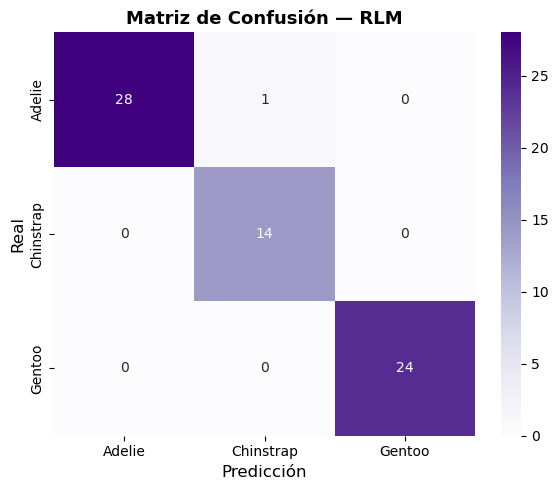


🎲 Probabilidades predichas (primeras 8 muestras del test):


,Real,Predicción,Adelie,Chinstrap,Gentoo,¿Correcto?
0,Gentoo,Gentoo,0.0002,0.0116,0.9882,True
1,Chinstrap,Chinstrap,0.0231,0.9703,0.0066,True
2,Adelie,Adelie,0.9904,0.0088,0.0009,True
3,Gentoo,Gentoo,0.0005,0.0042,0.9953,True
4,Gentoo,Gentoo,0.0009,0.0073,0.9918,True
5,Gentoo,Gentoo,0.0164,0.0028,0.9808,True
6,Chinstrap,Chinstrap,0.0086,0.9882,0.0032,True
7,Adelie,Adelie,0.9991,0.0001,0.0008,True



⚖️  Coeficientes por clase (+ = mayor probabilidad de esa clase):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male
Adelie,-2.336,0.803,-0.615,-0.262,0.030,-0.320,0.395,-0.390,0.390
Chinstrap,1.919,0.191,-0.251,-0.564,-0.686,0.884,-0.239,0.322,-0.322
Gentoo,0.417,-0.993,0.866,0.826,0.656,-0.564,-0.156,0.068,-0.068


In [44]:
# ── Entrenamiento Regresión Logística Multinomial ────────────



rlm = LogisticRegression(
    solver='lbfgs',              # Optimizador adecuado para multinomial
    max_iter=1000,               # Suficientes iteraciones para convergencia
    C=1.0,                       # Inverso de regularización L2 (1.0 = estándar)
    random_state=42
)
rlm.fit(X_train, y_train)

y_pred_rlm  = rlm.predict(X_test)
y_prob_rlm  = rlm.predict_proba(X_test)   # Probabilidades reales por clase

# ── Métricas ────────────────────────────────────────────────
print_metrics(y_test, y_pred_rlm, "Regresión Logística Multinomial")
plot_confusion_matrix(y_test, y_pred_rlm, "Matriz de Confusión — RLM")

# ── Probabilidades de las primeras predicciones ─────────────
print("\n🎲 Probabilidades predichas (primeras 8 muestras del test):")
prob_df = pd.DataFrame(y_prob_rlm[:8], columns=class_names).round(4)
prob_df.insert(0, 'Real',      [class_names[r] for r in y_test[:8]])
prob_df.insert(1, 'Predicción',[class_names[p] for p in y_pred_rlm[:8]])
prob_df['¿Correcto?'] = prob_df['Real'] == prob_df['Predicción']
display(prob_df)

# ── Coeficientes del modelo (interpretación) ────────────────
print("\n⚖️  Coeficientes por clase (+ = mayor probabilidad de esa clase):")
coef_df = pd.DataFrame(rlm.coef_, columns=feature_names, index=class_names)
display(coef_df.round(3))

### ⚠️ Limitaciones de RLM → ¿Por qué necesitamos algo más?

1. **Asume linealidad estricta:** Las fronteras de decisión son hiperplanos. Si la separación real entre clases requiere curvas, RLM no puede aprenderlas.
2. **No aprende representaciones intermedias:** RLM usa las features tal como son. No puede crear variables latentes que capturen patrones más abstractos o combinaciones complejas.
3. **Interacciones entre features:** No modela automáticamente interacciones entre variables (ej: la combinación específica de `bill_length` alto + `flipper_length` largo que distingue a Gentoo).

> 💡 **Siguiente paso:** Para capturar relaciones **no lineales** y aprender representaciones intermedias de los datos, necesitamos una arquitectura con **capas ocultas** — **Red Neuronal (MLP)**.

---
## 🟣 Bloque 7: Red Neuronal — Perceptrón Multicapa (MLP)

### ¿Qué es un MLP?
Un **Perceptrón Multicapa** (Multi-Layer Perceptron) es una red neuronal con:
- **Capa de entrada:** una neurona por feature de entrada (11 en nuestro caso)
- **Capas ocultas:** neuronas que aprenden representaciones intermedias y no lineales
- **Capa de salida:** una neurona por clase con activación softmax → probabilidades

### ¿Cómo aprende?
1. **Forward pass:** los datos pasan capa por capa aplicando `output = activación(W·x + b)`
2. **Función de pérdida:** se calcula el error entre predicción y etiqueta real (cross-entropy)
3. **Backpropagation:** el error se propaga hacia atrás calculando gradientes capa por capa
4. **Actualización de pesos:** el optimizador Adam ajusta W y b para minimizar el error
5. Se repite por muchas **épocas** hasta convergencia

### Arquitectura de nuestra red
```
Entrada (11) → Oculta (64, ReLU) → Oculta (32, ReLU) → Salida (3, Softmax)
```

---

> 💡 **Nota — Complejidad de implementar esto desde cero (al estilo McCulloch-Pitts):**
>
> Implementar esta red neuronal manualmente implicaría:
> - Definir matrices de pesos `W₁` (11×64), `W₂` (64×32) y `W₃` (32×3) con inicialización aleatoria
> - Programar ReLU: `f(x) = max(0, x)` y softmax: `σ(z)ₖ = exp(zₖ)/Σ exp(zⱼ)` como funciones Python puras
> - Implementar **backpropagation** completo: calcular ∂Loss/∂W₃, luego ∂Loss/∂W₂, luego ∂Loss/∂W₁ usando la regla de la cadena en cada capa
> - Programar el optimizador Adam con sus momentos de primer y segundo orden
> - Gestionar el ciclo de entrenamiento con mini-batches y early stopping
>
> Esto es viable para **1 neurona con salida binaria** (como vimos con McCulloch-Pitts en el ejercicio de cáncer de mama), pero para una red con **2 capas ocultas, 3 clases de salida y 11 features**, la complejidad matemática y de implementación se vuelve prohibitiva sin librerías especializadas.  
> `MLPClassifier` de scikit-learn realiza exactamente todo eso internamente.


════════════════════════════════════════════════════
  📈 Métricas — Red Neuronal (MLP)
════════════════════════════════════════════════════
  Accuracy  : 0.9701  (97.0%)
  F1-Macro  : 0.9632
  Precision : 0.9785
  Recall    : 0.9524
════════════════════════════════════════════════════

📐 Arquitectura: Entrada(9) → Oculta(64, ReLU) → Oculta(32, ReLU) → Salida(3, Softmax)
📐 Épocas hasta convergencia: 40
📐 Parámetros totales: 2819


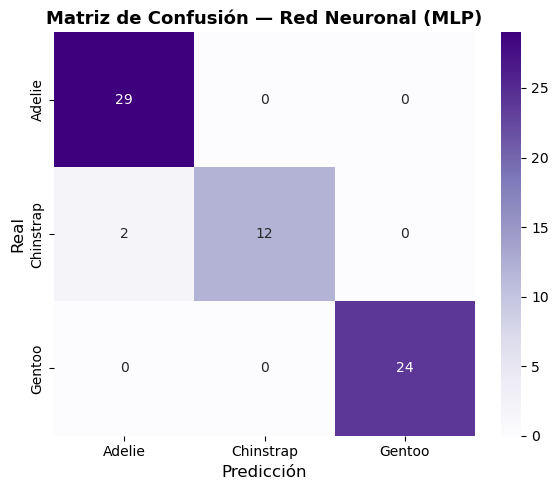

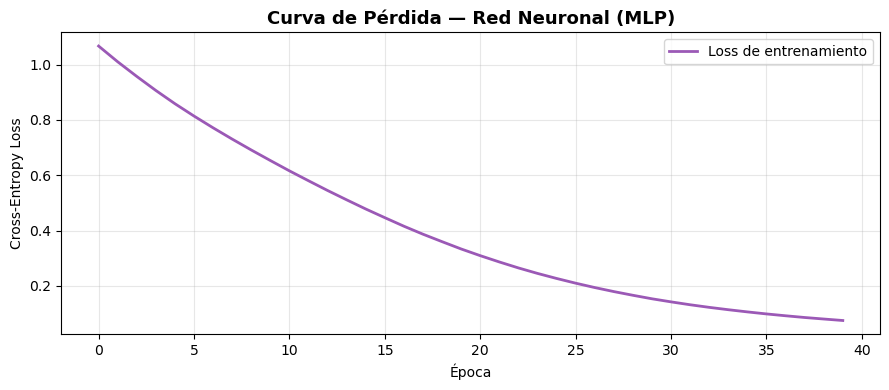

In [45]:
# ── Entrenamiento Red Neuronal (MLP) ────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 capas ocultas: 64 y 32 neuronas
    activation='relu',            # ReLU en capas ocultas: f(x) = max(0, x)
    solver='adam',                # Optimizador Adam: adaptativo y eficiente
    max_iter=1000,                # Máximo de épocas
    random_state=42,
    early_stopping=True,          # Detiene si la validación no mejora (evita overfitting)
    validation_fraction=0.1,      # 10% de train para monitoreo interno
    n_iter_no_change=20           # Épocas sin mejora antes de detener
)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

# ── Métricas ────────────────────────────────────────────────
print_metrics(y_test, y_pred_mlp, "Red Neuronal (MLP)")
print(f"\n📐 Arquitectura: Entrada({X_train.shape[1]}) → Oculta(64, ReLU) → Oculta(32, ReLU) → Salida(3, Softmax)")
print(f"📐 Épocas hasta convergencia: {mlp.n_iter_}")
print(f"📐 Parámetros totales: {sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)}")

plot_confusion_matrix(y_test, y_pred_mlp, "Matriz de Confusión — Red Neuronal (MLP)")

# ── Curva de pérdida ────────────────────────────────────────
# Muestra cómo el error disminuye durante el entrenamiento
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mlp.loss_curve_, color='#9b59b6', linewidth=2, label='Loss de entrenamiento')
ax.set_title('Curva de Pérdida — Red Neuronal (MLP)', fontsize=13, fontweight='bold')
ax.set_xlabel('Época'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 📊 Bloque 8: Tabla Comparativa de Modelos

Ahora que todos los modelos están entrenados y evaluados, comparamos su desempeño.

> 🎯 **Objetivo de esta comparativa:** Mostrar que la elección de modelo no siempre es sobre máxima precisión — también importa la **interpretabilidad**, la **velocidad de entrenamiento** y si el problema requiere probabilidades.

📊 Tabla Comparativa de Todos los Modelos


,Accuracy,F1-Macro,Precision,Recall
Modelo,,,,
SVM (kernel RBF),0.9851,0.9827,0.9778,0.9885
Regresión Logística Multinomial,0.9851,0.9827,0.9778,0.9885
Red Neuronal (MLP),0.9701,0.9632,0.9785,0.9524
Árbol de Decisión,0.9552,0.9518,0.9468,0.9607
K-Means,0.7910,0.6019,0.5581,0.6667


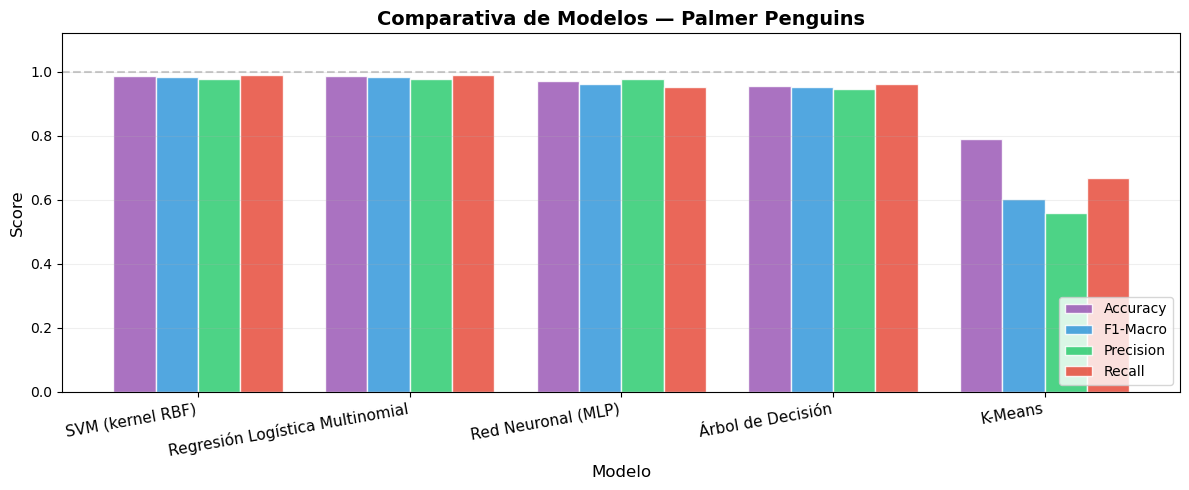

In [46]:
# ── Tabla comparativa de métricas ───────────────────────────
df_res = pd.DataFrame(resultados).T
df_res.index.name = 'Modelo'

# Ordenar por Accuracy descendente
df_res = df_res.sort_values('Accuracy', ascending=False)

print("📊 Tabla Comparativa de Todos los Modelos")
print("="*60)
display(df_res.style
        .background_gradient(cmap='Purples', axis=0)
        .format("{:.4f}")
        .set_caption("Métricas evaluadas en el conjunto de test (20% de los datos)"))

# ── Gráfica de barras comparativa ──────────────────────────
metricas = ['Accuracy', 'F1-Macro', 'Precision', 'Recall']
colors   = ['#9b59b6', '#3498db', '#2ecc71', '#e74c3c']
x     = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metrica, color) in enumerate(zip(metricas, colors)):
    ax.bar(x + i*width, df_res[metrica], width, label=metrica,
           color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparativa de Modelos — Palmer Penguins', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_res.index, rotation=10, ha='right', fontsize=11)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.12)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout(); plt.show()

---
## 🔮 Bloque 9: Demo de Inferencia

Demostramos que los modelos **funcionan con datos completamente nuevos**, no solo con el conjunto de test.

Creamos un pingüino ficticio con características específicas y pedimos a cada modelo que lo clasifique:

> 🐧 **Pingüino de prueba:**  
> - Isla: **Dream**  
> - Pico: **46 mm** de largo, **15 mm** de profundidad  
> - Aleta: **215 mm**  
> - Masa: **4,800 g**  
> - Sexo: **Macho**  
>
> *(Características típicas de un pingüino Gentoo)*

In [47]:
# ── Definir pingüino nuevo ──────────────────────────────────
# Las columnas deben coincidir EXACTAMENTE con df_encoded (mismo orden)
nuevo_raw = {
    'bill_length_mm':    46.0,
    'bill_depth_mm':     15.0,
    'flipper_length_mm': 215.0,
    'body_mass_g':       4800.0,
    # One-Hot: island
    'island_Biscoe':     0,
    'island_Dream':      1,
    'island_Torgersen':  0,
    # One-Hot: sex
    'sex_Female':        0,
    'sex_Male':          1,
}

# Construir vector en el mismo orden de features
X_nuevo      = pd.DataFrame([nuevo_raw])[feature_names].values.astype(float)
X_nuevo_scaled = scaler.transform(X_nuevo)   # Escalar con el mismo scaler del entrenamiento

# ── Predicciones de cada modelo ─────────────────────────────
print("🐧 Predicciones para el pingüino nuevo")
print("="*60)

# K-Means
cluster_nuevo = kmeans.predict(X_nuevo_scaled)[0]
especie_kmeans = class_names[label_map.get(int(cluster_nuevo), int(cluster_nuevo))]
print(f"  {'K-Means':<28}: Cluster {cluster_nuevo} → {especie_kmeans}")

# Modelos con probabilidades
modelos_prob = {
    "SVM (kernel RBF)":          svm,
    "Árbol de Decisión":         arbol,
    "Regresión Logística (RLM)": rlm,
    "Red Neuronal (MLP)":        mlp,
}

pred_rows = []
for nombre, modelo in modelos_prob.items():
    pred  = modelo.predict(X_nuevo_scaled)[0]
    proba = modelo.predict_proba(X_nuevo_scaled)[0]
    clase = class_names[pred]
    proba_str = "  |  ".join([f"{class_names[i]}: {proba[i]:.1%}" for i in range(3)])
    print(f"  {nombre:<28}: {clase:<12}  [{proba_str}]")
    pred_rows.append({'Modelo': nombre, 'Predicción': clase,
                      **{class_names[i]: f"{proba[i]:.1%}" for i in range(3)}})

print("="*60)
print("\n📋 Tabla de probabilidades:")
display(pd.DataFrame(pred_rows).set_index('Modelo'))

🐧 Predicciones para el pingüino nuevo
  K-Means                     : Cluster 2 → Adelie
  SVM (kernel RBF)            : Adelie        [Adelie: 42.3%  |  Chinstrap: 36.8%  |  Gentoo: 20.8%]
  Árbol de Decisión           : Gentoo        [Adelie: 0.0%  |  Chinstrap: 0.0%  |  Gentoo: 100.0%]
  Regresión Logística (RLM)   : Gentoo        [Adelie: 5.0%  |  Chinstrap: 31.2%  |  Gentoo: 63.8%]
  Red Neuronal (MLP)          : Gentoo        [Adelie: 36.4%  |  Chinstrap: 25.0%  |  Gentoo: 38.7%]

📋 Tabla de probabilidades:


,Predicción,Adelie,Chinstrap,Gentoo
Modelo,,,,
SVM (kernel RBF),Adelie,42.3%,36.8%,20.8%
Árbol de Decisión,Gentoo,0.0%,0.0%,100.0%
Regresión Logística (RLM),Gentoo,5.0%,31.2%,63.8%
Red Neuronal (MLP),Gentoo,36.4%,25.0%,38.7%


---
## ✅ Bloque 10: Conclusiones

### Resumen del recorrido

| Modelo | Supervisado | Interpretable | Probabilidades | Complejidad |
|--------|:-----------:|:-------------:|:--------------:|:-----------:|
| K-Means | ❌ | ⚠️ (clusters) | ❌ | ⬇️ Baja |
| SVM | ✅ | ❌ | ✅ | ⬆️ Media |
| Árbol | ✅ | ✅✅ | ⚠️ (aproximada) | ⬇️ Baja |
| RLM | ✅ | ✅ | ✅✅ | ⬇️ Baja |
| MLP (Neurona) | ✅ | ❌ | ✅ | ⬆️⬆️ Alta |

### Reflexión final

> No existe un modelo universalmente mejor. La elección depende del **contexto**:
>
> - 🔍 Si necesitas **explorar datos sin etiquetas**: K-Means como punto de partida
> - 📖 Si necesitas **explicar cada predicción**: Árbol de Decisión o RLM
> - 🎯 Si necesitas **probabilidades confiables**: RLM o MLP
> - 🏆 Si necesitas **máxima precisión** sin importar interpretabilidad: MLP o SVM
> - ⚡ Si el dataset es enorme y el tiempo importa: RLM (muy rápido de entrenar)

### ¿Por qué terminar con la Neurona?
La red neuronal MLP representa el cierre natural de este recorrido: es el único modelo que puede aprender **representaciones no lineales y jerárquicas** de los datos. Sus capas ocultas funcionan como "detectores de patrones" cada vez más abstractos — lo que sienta las bases para arquitecturas más profundas como CNNs, RNNs y Transformers.

---
*Dataset: Palmer Penguins — Horst AM, Hill AP, Gorman KB (2020)*